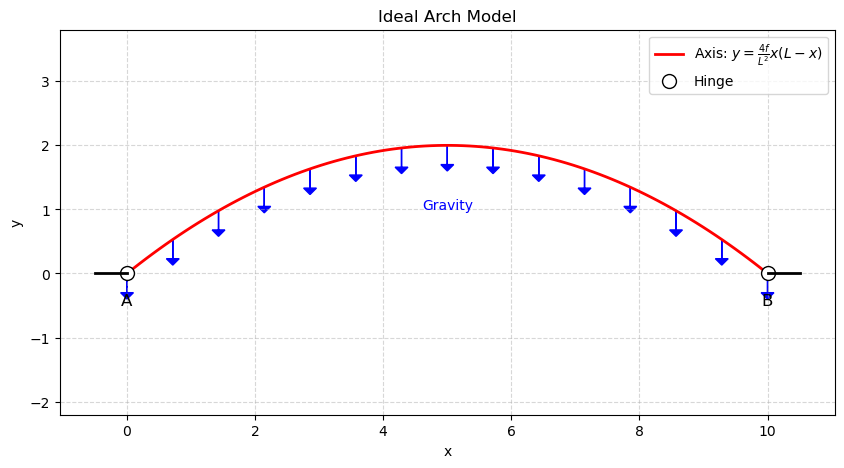

In [5]:
import numpy as np
import matplotlib.pyplot as plt


L = 10.0 
f = 2.0   
q_arrows = 15  

x = np.linspace(0, L, 100)
y = (4 * f / L**2) * x * (L - x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, 'r-', linewidth=2, label=f'Axis: $y = \\frac{{4f}}{{L^2}}x(L-x)$')

plt.plot(0, 0, 'wo', markersize=10, markeredgecolor='k', linewidth=2, label='Hinge')
plt.plot(L, 0, 'wo', markersize=10, markeredgecolor='k', linewidth=2)
plt.plot([-0.5, 0], [0, 0], 'k-', linewidth=2)  
plt.plot([L, L+0.5], [0, 0], 'k-', linewidth=2)

x_load = np.linspace(0, L, q_arrows)
y_load = (4 * f / L**2) * x_load * (L - x_load)
for xi, yi in zip(x_load, y_load):
    plt.arrow(xi, yi, 0, -0.3, head_width=0.2, head_length=0.1, fc='b', ec='b')

plt.text(L/2, f/2, f'Gravity', color='b', ha='center')
plt.text(0, -0.5, 'A', ha='center', fontsize=12)
plt.text(L, -0.5, 'B', ha='center', fontsize=12)

plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.title('Ideal Arch Model')
plt.show()

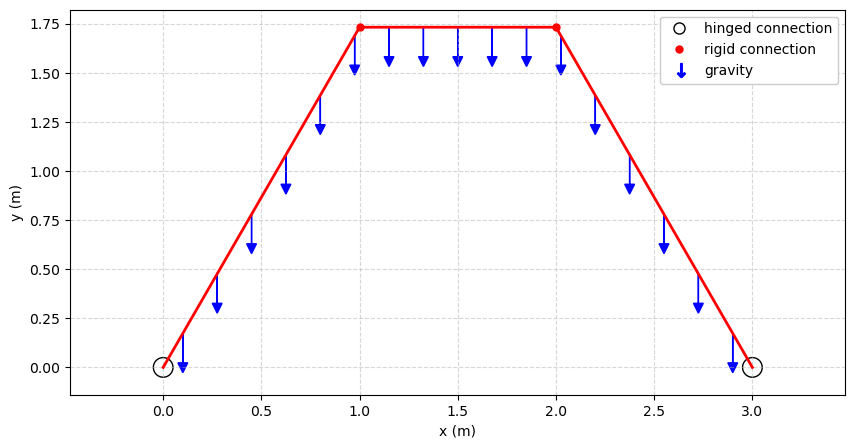

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

support_A = (0, 0)
support_B = (3, 0)
node_C = (1, np.sqrt(3))
node_D = (2, np.sqrt(3))

plt.figure(figsize=(10, 5))
ax = plt.gca()

plt.plot([support_A[0], node_C[0], node_D[0], support_B[0]], 
         [support_A[1], node_C[1], node_D[1], support_B[1]], 
         'r-', linewidth=2)

ax.add_patch(Circle(support_A, radius=0.05, facecolor='w', edgecolor='k', linewidth=1))
ax.add_patch(Circle(support_B, radius=0.05, facecolor='w', edgecolor='k', linewidth=1))

plt.plot(node_C[0], node_C[1], 'ro', markersize=5)
plt.plot(node_D[0], node_D[1], 'ro', markersize=5)

x_load = np.linspace(0.1, 2.9, 17)
for xi in x_load:
    if xi <= 1:
        yi = np.sqrt(3) * xi
    elif xi <= 2:
        yi = np.sqrt(3)
    else:
        yi = np.sqrt(3) * (3 - xi)
    plt.arrow(xi, yi, 0, -0.15, head_width=0.05, head_length=0.05, fc='b', ec='b')

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='hinged connection',
               markerfacecolor='w', markeredgecolor='k', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='rigid connection',
               markerfacecolor='r', markeredgecolor='r', markersize=5),
    plt.Line2D([0], [0], color='b', marker='$\u2193$', linestyle='None',
               label='gravity', markersize=10)
]
plt.legend(handles=legend_elements, loc='upper right', framealpha=1)

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Problem description:
This problem imitates the famous ideal model of bending-free arch; while the original arch model y(x) is continous, this specific model is not. For which, we have to modify the problem so it follows the mechanical essence of a continous one. 

Such that, the problem is formulated, the requirement of pure axial region is limited to the both side edges (with continuous y(x)). 

## Value Specification:
1. the gravity : 1KN/m
2. the free nodes (red) range (naming them from left to right node1 and node2): 
   
   a. x(node1) from 0m to 1.5m<br>
   b. x(node2) from 1.5m to 2.0m<br>
   c. both ys from 0m to 2.0m
   

## Static Analysis:

### First we analyze the forces to the y direction to construct bending & axial equilibrium as follows:

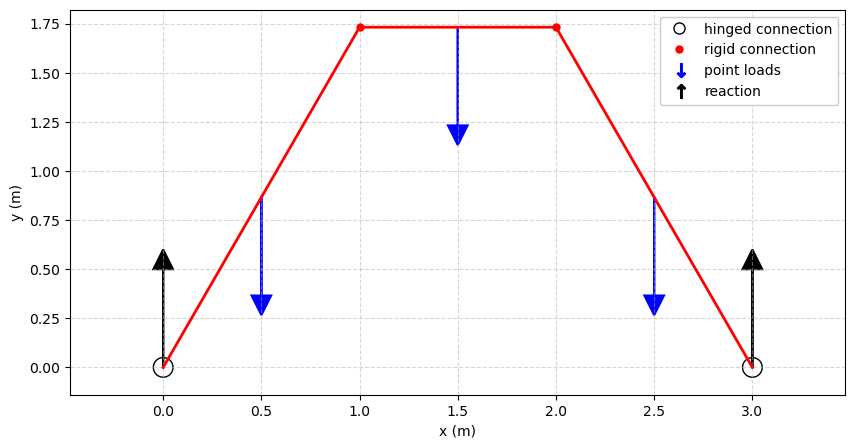

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

support_A = (0, 0)
support_B = (3, 0)
node_C = (1, np.sqrt(3))
node_D = (2, np.sqrt(3))

plt.figure(figsize=(10, 5))
ax = plt.gca()

plt.plot([support_A[0], node_C[0], node_D[0], support_B[0]], 
         [support_A[1], node_C[1], node_D[1], support_B[1]], 
         'r-', linewidth=2)

ax.add_patch(Circle(support_A, radius=0.05, facecolor='w', edgecolor='k', linewidth=1))
ax.add_patch(Circle(support_B, radius=0.05, facecolor='w', edgecolor='k', linewidth=1))

plt.plot(node_C[0], node_C[1], 'ro', markersize=5)
plt.plot(node_D[0], node_D[1], 'ro', markersize=5)

arrow_points = [
    (0.5, np.sqrt(3)/2),
    (1.5, np.sqrt(3)),
    (2.5, np.sqrt(3)/2)
]

for xi, yi in arrow_points:
    plt.arrow(xi, yi, 0, -0.5, head_width=0.1, head_length=0.1, fc='b', ec='b', linewidth=1.5)

ax.arrow(0, 0, 0, 0.5, head_width=0.1, head_length=0.1, fc='k', ec='k', linewidth=1.5)
ax.arrow(3.0, 0, 0, 0.5, head_width=0.1, head_length=0.1, fc='k', ec='k', linewidth=1.5)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='hinged connection',
               markerfacecolor='w', markeredgecolor='k', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='rigid connection',
               markerfacecolor='r', markeredgecolor='r', markersize=5),
    plt.Line2D([0], [0], color='b', marker='$\u2193$', linestyle='None',
               label='point loads', markersize=10),
    plt.Line2D([0], [0], color='k', marker='$\u2191$', linestyle='None',
               label='reaction', markersize=10)
]
plt.legend(handles=legend_elements, loc='upper right', framealpha=1)

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### For for reaction forces to the x direction it is a biy of tricky (as to astmmetric geometry) <br>
We could do with existing analysis framework by adding two different types of full-fixed configuration:

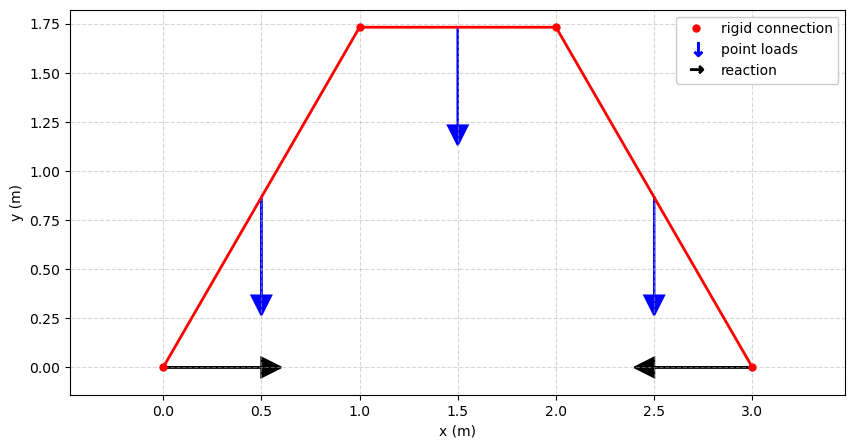

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

support_A = (0, 0)
support_B = (3, 0)
node_C = (1, np.sqrt(3))
node_D = (2, np.sqrt(3))

plt.figure(figsize=(10, 5))
ax = plt.gca()

# Draw the structure
plt.plot([support_A[0], node_C[0], node_D[0], support_B[0]], 
         [support_A[1], node_C[1], node_D[1], support_B[1]], 
         'r-', linewidth=2)

# Draw the nodes (removed the white circles)
plt.plot(support_A[0], support_A[1], 'ro', markersize=5)
plt.plot(support_B[0], support_B[1], 'ro', markersize=5)
plt.plot(node_C[0], node_C[1], 'ro', markersize=5)
plt.plot(node_D[0], node_D[1], 'ro', markersize=5)

# Point loads (blue downward arrows)
arrow_points = [
    (0.5, np.sqrt(3)/2),
    (1.5, np.sqrt(3)),
    (2.5, np.sqrt(3)/2)
]

for xi, yi in arrow_points:
    plt.arrow(xi, yi, 0, -0.5, head_width=0.1, head_length=0.1, fc='b', ec='b', linewidth=1.5)

# Add horizontal reaction arrows (black arrows in x-direction)
ax.arrow(0, 0, 0.5, 0, head_width=0.1, head_length=0.1, fc='k', ec='k', linewidth=1.5)
ax.arrow(3.0, 0, -0.5, 0, head_width=0.1, head_length=0.1, fc='k', ec='k', linewidth=1.5)

# Modified legend (removed hinge connection entry)
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='rigid connection',
               markerfacecolor='r', markeredgecolor='r', markersize=5),
    plt.Line2D([0], [0], color='b', marker='$\u2193$', linestyle='None',
               label='point loads', markersize=10),
    plt.Line2D([0], [0], color='k', marker='$\u2192$', linestyle='None',
               label='reaction', markersize=10)
]
plt.legend(handles=legend_elements, loc='upper right', framealpha=1)

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Adding with the following configuration. For moment they are in the opposite direction to the bove momoent resultants.

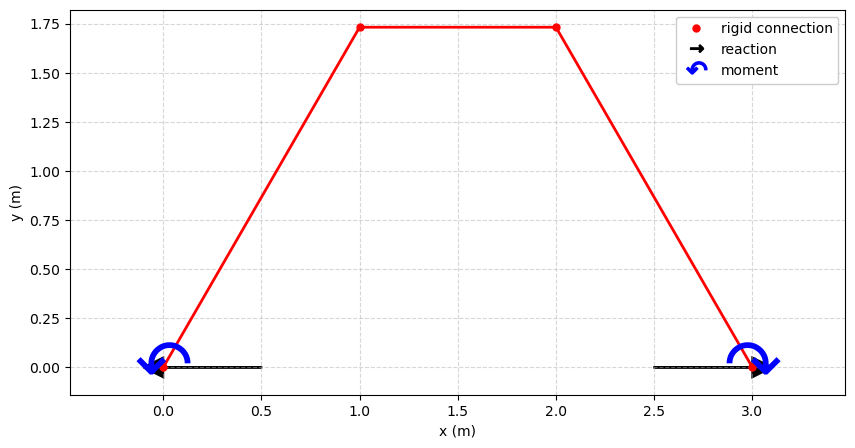

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

support_A = (0, 0)
support_B = (3, 0)
node_C = (1, np.sqrt(3))
node_D = (2, np.sqrt(3))

plt.figure(figsize=(10, 5))
ax = plt.gca()

plt.plot([support_A[0], node_C[0], node_D[0], support_B[0]], 
         [support_A[1], node_C[1], node_D[1], support_B[1]], 
         'r-', linewidth=2)

plt.plot(support_A[0], support_A[1], 'ro', markersize=5)
plt.plot(support_B[0], support_B[1], 'ro', markersize=5)
plt.plot(node_C[0], node_C[1], 'ro', markersize=5)
plt.plot(node_D[0], node_D[1], 'ro', markersize=5)

ax.arrow(0.5, 0, -0.5, 0, head_width=0.1, head_length=0.1, fc='k', ec='k', linewidth=1.5)  # 左侧箭头反向
ax.arrow(2.5, 0, 0.5, 0, head_width=0.1, head_length=0.1, fc='k', ec='k', linewidth=1.5)   # 右侧箭头反向

plt.text(0, 0, r'$\curvearrowleft$', fontsize=50, color='blue', ha='center', va='center')  # 左侧支座
plt.text(3, 0, r'$\curvearrowright$', fontsize=50, color='blue', ha='center', va='center')  # 右侧支座

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='rigid connection',
               markerfacecolor='r', markeredgecolor='r', markersize=5),
    plt.Line2D([0], [0], color='k', marker='$\u2192$', linestyle='None',
               label='reaction', markersize=10),
    plt.Line2D([0], [0], color='blue', marker='$\curvearrowleft$', linestyle='None',
               label='moment', markersize=15)
]
plt.legend(handles=legend_elements, loc='upper right', framealpha=1)

plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Analysis framework

## The Beam class

In [11]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import plotly.graph_objects as go
import time
from datetime import timedelta
import json
import os
import psutil
import gc
import math

In [12]:
###### FE part
D_radius = 0.75
D_young_modulus = 10e9 
D_shear_modulus = 0.7e9 
D_poisson_ratio = 0.3
cross_section_angle_a = 0  
cross_section_angle_b = 0  
a_small_number = 1e-10

def rotation(v, k, theta):
    """Rotation of vector v around axis k by angle theta."""
    k = k / torch.norm(k)  # Normalize k
    cross_product = torch.cross(k, v)
    dot_product = torch.dot(k, v)

    # Ensure theta is a tensor
    theta = torch.tensor(theta, dtype=torch.float32, device=device) if not isinstance(theta, torch.Tensor) else theta

    v_rotated = v * torch.cos(theta) + cross_product * torch.sin(theta) + k * dot_product * (1 - torch.cos(theta))
    return v_rotated

class Beam:
    def __init__(self, node_coordinates, R=D_radius, young_modulus=D_young_modulus,
                 shear_modulus=D_shear_modulus, poisson_ratio=D_poisson_ratio, Beta_a=cross_section_angle_a,
                 Beta_b=cross_section_angle_b):
        self.node_coordinates = node_coordinates  # (2, 3) tensor for node coordinates

        # Material and geometry
        self.radius = R
        self.young_modulus = young_modulus
        self.shear_modulus = shear_modulus
        self.poisson_ratio = poisson_ratio

        # Cross-sectional properties
        self.length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])  # Length of the beam
        self.Iy = (torch.pi * self.radius ** 4) / 4 
        self.Iz = self.Iy
        self.A = torch.pi * self.radius ** 2
        self.J = (torch.pi * self.radius ** 4) / 2

        # Stiffness components
        self.S_u = self.young_modulus * self.A / self.length
        self.S_v1a = 12 * self.young_modulus * self.Iy / (self.length ** 3)
        self.S_v1b = 6 * self.young_modulus * self.Iy / (self.length ** 2)
        self.S_v2a = 12 * self.young_modulus * self.Iz / (self.length ** 3)
        self.S_v2b = 6 * self.young_modulus * self.Iz / (self.length ** 2)
        self.S_theta1a = 6 * self.young_modulus * self.Iy / (self.length ** 2)
        self.S_theta1b = 4 * self.young_modulus * self.Iy / self.length
        self.S_theta1c = 2 * self.young_modulus * self.Iy / self.length
        self.S_theta2a = 6 * self.young_modulus * self.Iz / (self.length ** 2)
        self.S_theta2b = 4 * self.young_modulus * self.Iz / self.length
        self.S_theta2c = 2 * self.young_modulus * self.Iz / self.length
        self.S_Tr = self.shear_modulus * self.J / self.length

        # Section rotations at the two ends
        self.Beta_a = Beta_a
        self.Beta_b = Beta_b

    def get_element_stiffness_matrix(self):
        """Element stiffness matrix."""
        K_element = torch.tensor([
            [self.S_u, 0, 0, 0, 0, 0, -self.S_u, 0, 0, 0, 0, 0],
            [0, self.S_v1a, 0, 0, 0, self.S_theta1a, 0, -self.S_v1a, 0, 0, 0, self.S_theta1a],
            [0, 0, self.S_v2a, 0, -self.S_theta2a, 0, 0, 0, -self.S_v2a, 0, -self.S_theta2a, 0],
            [0, 0, 0, self.S_Tr, 0, 0, 0, 0, 0, -self.S_Tr, 0, 0],
            [0, 0, -self.S_v2b, 0, self.S_theta2b, 0, 0, 0, self.S_v2b, 0, self.S_theta2c, 0],
            [0, self.S_v1b, 0, 0, 0, self.S_theta1b, 0, -self.S_v1b, 0, 0, 0, self.S_theta1c],
            [-self.S_u, 0, 0, 0, 0, 0, self.S_u, 0, 0, 0, 0, 0],
            [0, -self.S_v1a, 0, 0, 0, -self.S_theta1a, 0, self.S_v1a, 0, 0, 0, -self.S_theta1a],
            [0, 0, -self.S_v2a, 0, self.S_theta2a, 0, 0, 0, self.S_v2a, 0, self.S_theta2a, 0],
            [0, 0, 0, -self.S_Tr, 0, 0, 0, 0, 0, self.S_Tr, 0, 0],
            [0, 0, -self.S_v2b, 0, self.S_theta2c, 0, 0, 0, self.S_v2b, 0, self.S_theta2b, 0],
            [0, self.S_v1b, 0, 0, 0, self.S_theta1c, 0, -self.S_v1b, 0, 0, 0, self.S_theta1b],
        ], dtype=torch.float32, device=device)

        return K_element

    def System_Transform(self):
        """Coordinate transformation matrix."""
        vector_x = self.node_coordinates[1, 0] - self.node_coordinates[0, 0]
        vector_y = self.node_coordinates[1, 1] - self.node_coordinates[0, 1]
        vector_z = self.node_coordinates[1, 2] - self.node_coordinates[0, 2]
        length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])
        
        z_value = torch.clamp(vector_z / length, min=-1 + 1e-6, max=1 - 1e-6)
        ceta = torch.acos(z_value)
        value = vector_x / torch.sqrt(vector_y ** 2 + vector_x ** 2 + a_small_number)
        value = torch.clamp(value, min=-1 + 1e-6, max=1 - 1e-6)
        alpha = torch.acos(value)

        Projection_Z_x = - vector_z / length * torch.sin(alpha)
        Projection_Z_y = - vector_z / length * torch.cos(alpha)
        Projection_Z_z = torch.cos(torch.pi / 2 - ceta)

        V_projection = torch.stack([Projection_Z_x, Projection_Z_y, Projection_Z_z])
        X_axis = torch.stack([vector_x / length, vector_y / length, vector_z / length])
        Z_axis_a = rotation(V_projection, X_axis, self.Beta_a)
        Y_axis_a = rotation(Z_axis_a, X_axis, -torch.pi / 2)
        Z_axis_a = Z_axis_a / torch.norm(Z_axis_a)
        Y_axis_a = Y_axis_a / torch.norm(Y_axis_a)

        lambda_matrix = torch.stack([X_axis, Y_axis_a, Z_axis_a], dim=0)
        matrix_T = torch.zeros((12, 12), dtype=torch.float32, device=device)
        for i in range(0, 12, 3):
            matrix_T[i:i + 3, i:i + 3] = lambda_matrix
        return matrix_T

    def nodal_transform(self):
        """Coordinate transformation matrix."""
        vector_x = self.node_coordinates[1, 0] - self.node_coordinates[0, 0]
        vector_y = self.node_coordinates[1, 1] - self.node_coordinates[0, 1]
        vector_z = self.node_coordinates[1, 2] - self.node_coordinates[0, 2]
        length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])
        
        z_value = torch.clamp(vector_z / length, min=-1 + 1e-6, max=1 - 1e-6)
        ceta = torch.acos(z_value)
        value = vector_x / torch.sqrt(vector_y ** 2 + vector_x ** 2 + a_small_number)
        value = torch.clamp(value, min=-1 + 1e-6, max=1 - 1e-6)
        alpha = torch.acos(value)

        Projection_Z_x = - vector_z / length * torch.sin(alpha)
        Projection_Z_y = - vector_z / length * torch.cos(alpha)
        Projection_Z_z = torch.cos(torch.pi / 2 - ceta)

        V_projection = torch.stack([Projection_Z_x, Projection_Z_y, Projection_Z_z])
        X_axis = torch.stack([vector_x / length, vector_y / length, vector_z / length])
        Z_axis_a = rotation(V_projection, X_axis, self.Beta_a)
        Y_axis_a = rotation(Z_axis_a, X_axis, -torch.pi / 2)
        Z_axis_a = Z_axis_a / torch.norm(Z_axis_a)
        Y_axis_a = Y_axis_a / torch.norm(Y_axis_a)

        lambda_matrix = torch.stack([X_axis, Y_axis_a, Z_axis_a], dim=0)
        return lambda_matrix


def assemble_stiffness_matrix(beams, n_nodes, n_dof_per_node, connectivity):
    """Global stiffness matrix assembly."""
    total_dof = n_nodes * n_dof_per_node  # Total degrees of freedom
    K_global = torch.zeros((total_dof, total_dof), dtype=torch.float32, device=device)
    
    for idx, (i, j) in enumerate(connectivity):
        Matrix_T = beams[idx].System_Transform()  # Get transformation matrix
        K_element = torch.matmul(torch.transpose(Matrix_T, 0, 1),
                                 torch.matmul(beams[idx].get_element_stiffness_matrix(), Matrix_T))

        start_idx = (i - 1) * n_dof_per_node
        end_idx = (j - 1) * n_dof_per_node
        K_global[start_idx:start_idx + 6, start_idx:start_idx + 6] += K_element[0:6, 0:6]
        K_global[end_idx:end_idx + 6, end_idx:end_idx + 6] += K_element[6:12, 6:12]
        K_global[start_idx:start_idx + 6, end_idx:end_idx + 6] += K_element[0:6, 6:12]
        K_global[end_idx:end_idx + 6, start_idx:start_idx + 6] += K_element[6:12, 0:6]

    return K_global

def robust_solve(K_global, F, fixed_dof, max_attempts=3):
    
    attempts = 0
    while attempts < max_attempts:
        reg = 1e-6 * torch.eye(K_global.shape[0], device=K_global.device)
        reg[fixed_dof, fixed_dof] = 0  
        K_reg = K_global + reg
        
        try:
            displacements = torch.linalg.solve(
                K_reg.to(torch.float64), 
                F.to(torch.float64)
            )
            return displacements.to(K_global.dtype)
            
        except RuntimeError:
            diag = torch.diag(K_global)
            extreme_mask = (diag > 1e12) & (~torch.isin(torch.arange(len(diag)), torch.tensor(fixed_dof)))  
            K_reg[extreme_mask] = 0
            K_reg[:, extreme_mask] = 0
            K_reg[extreme_mask, extreme_mask] = 1e12  
            
            K_reg[fixed_dof, :] = 0
            K_reg[:, fixed_dof] = 0
            K_reg[fixed_dof, fixed_dof] = 1e10  
            
            try:
                displacements, info = torch.linalg.cg(
                    K_reg.to(torch.float64),
                    F.to(torch.float64),
                    maxiter=5000,
                    atol=1e-6
                )
                if info > 0:
                    raise RuntimeError("CG nah nah")
                return displacements.to(K_global.dtype)
                
            except:
                K_pinv = torch.linalg.pinv(K_reg)
                K_pinv[fixed_dof, :] = 0  
                displacements = K_pinv @ F
                print("警告：使用伪逆求解，精度可能降低")
                return displacements
                
        attempts += 1
    
    raise RuntimeError("无法求解线性系统")


def Strain_E(node_coords, connectivity, fixed_dof, F):
    # Element Assembly
    Beam_lens = []
    beams = []
    for connection in connectivity:
        node_1_coords = node_coords[connection[0] - 1]
        node_2_coords = node_coords[connection[1] - 1]
        beam = Beam(node_coordinates=torch.stack([node_1_coords, node_2_coords]),
                    R=D_radius, young_modulus=D_young_modulus,
                    shear_modulus=D_shear_modulus, poisson_ratio=D_poisson_ratio, Beta_a=cross_section_angle_a,
                    Beta_b=cross_section_angle_b)
        beams.append(beam)
        Beam_lens.append(beam.length)
    
    # Stiffness renewal
    K_global = assemble_stiffness_matrix(beams, n_nodes=len(node_coords), n_dof_per_node=6, connectivity=connectivity)
    K_global[fixed_dof, :] = 0
    K_global[:, fixed_dof] = 0
    K_global[fixed_dof, fixed_dof] = 1e10

    displacements = robust_solve(K_global, F, fixed_dof)

    # Compute strain energy
    strain_energy_list = []
    force_list = []
    ASE_list = []
    V_list = []
    Local_d = torch.zeros(len(connectivity), 12, dtype=torch.float32, device=device)
    for n, (i, j) in enumerate(connectivity):
        matrix_T = beams[n].System_Transform()
        Tep_displacements = torch.cat(
            [displacements[6 * (i - 1):6 * (i - 1) + 6], displacements[6 * (j - 1):6 * (j - 1) + 6]], dim=0)
        Local_d_n = torch.matmul(Tep_displacements, matrix_T.T)
        Local_d[n, :] = Local_d_n.clone()
        K_l = beams[n].get_element_stiffness_matrix()
        strain_energy_list.append(0.5 * torch.matmul(Local_d_n, torch.matmul(K_l, Local_d_n.reshape(-1, 1))))
        force_list.append(torch.matmul(K_l, Local_d_n.reshape(-1, 1)))
        ASE_list.append(0.5 * (Local_d_n[0]-Local_d_n[6]) * beams[n].S_u * (Local_d_n[0]-Local_d_n[6]))  
        V_list.append(beams[n].A * beams[n].length)
    
     
    
    Strain_energy = torch.stack(strain_energy_list)
    forces = torch.stack(force_list)
    ASE = torch.stack(ASE_list)
    lens = torch.stack(Beam_lens)
    # epsilon = Local_d[:, 0] / lens
    # Axial_d = Local_d[:, 0]
    V = torch.stack(V_list)
    SED = Strain_energy / lens 
    R = torch.var(SED)
    
    return Strain_energy, forces, displacements, ASE, lens, R, V

##  Geometry Sampling

tensor([    0.0000,     0.0000,     0.0000,     0.0000,   -78.9077,     0.0000,
            0.0000,     0.0000,  -765.4384,     0.0000,  -155.8648,     0.0000,
            0.0000,     0.0000, -1219.0950,     0.0000,  -304.8083,     0.0000,
            0.0000,     0.0000,     0.0000,     0.0000,   539.5808,     0.0000])
tensor([ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00, -5.0842e+02,
         0.0000e+00,  0.0000e+00,  0.0000e+00, -1.4774e+03,  0.0000e+00,
        -7.5882e+01,  0.0000e+00,  0.0000e+00,  0.0000e+00, -7.8696e+02,
         0.0000e+00,  5.8379e+02,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  5.0930e-01,  0.0000e+00])
tensor([    0.0000,     0.0000,     0.0000,     0.0000,  -301.3960,     0.0000,
            0.0000,     0.0000, -1374.3320,     0.0000,  -379.7844,     0.0000,
            0.0000,     0.0000,  -951.0045,     0.0000,   665.3879,     0.0000,
            0.0000,     0.0000,     0.0000,     0.0000,    15.7925,     0.0000])
tenso

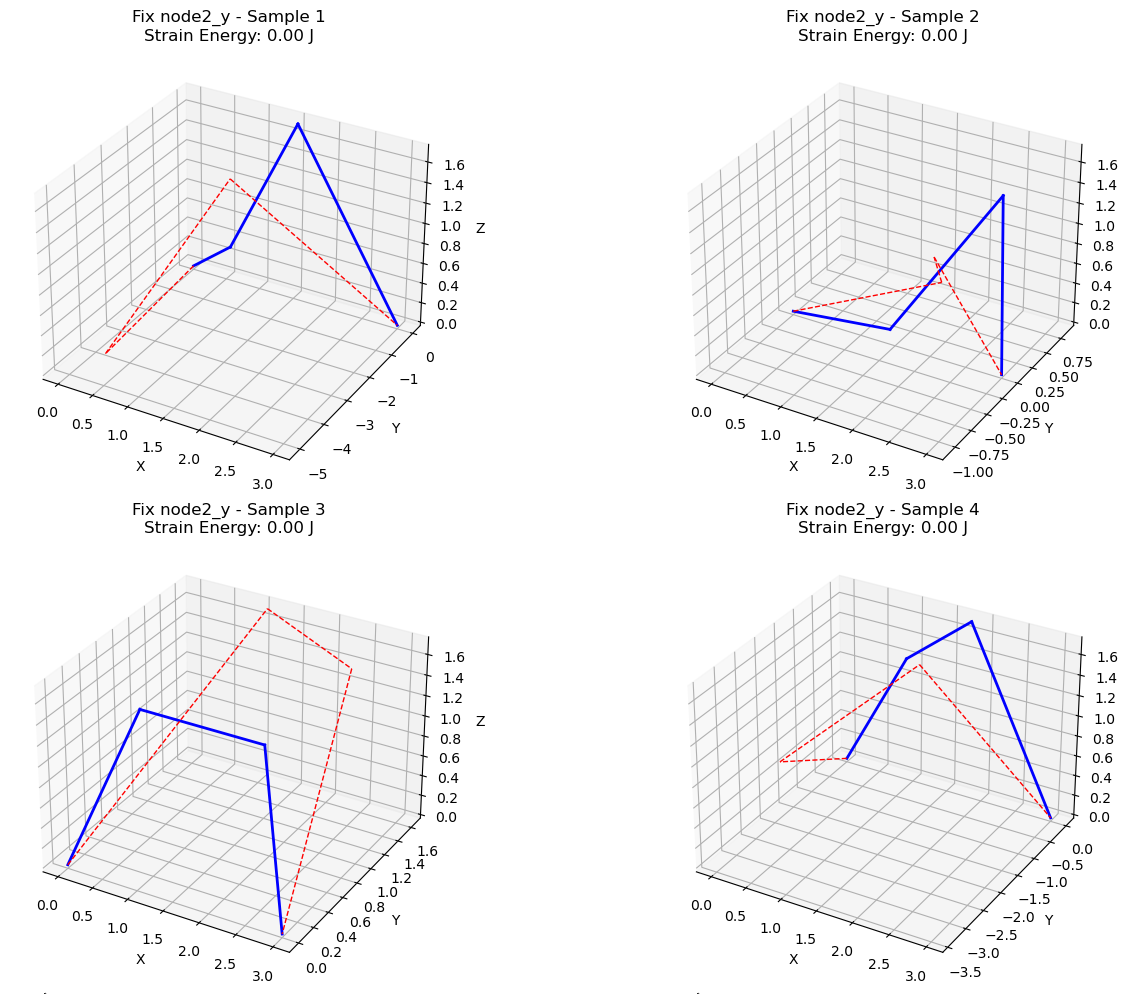

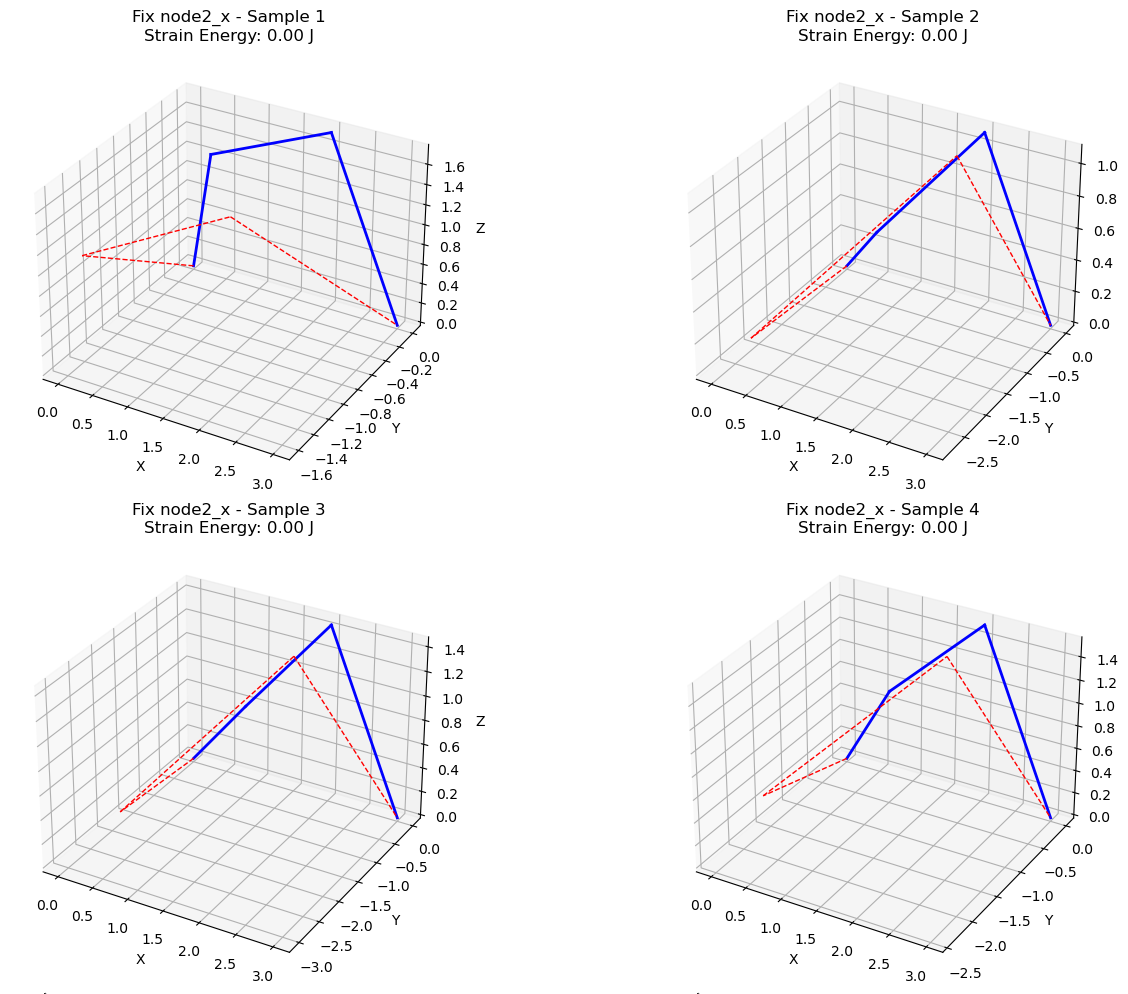

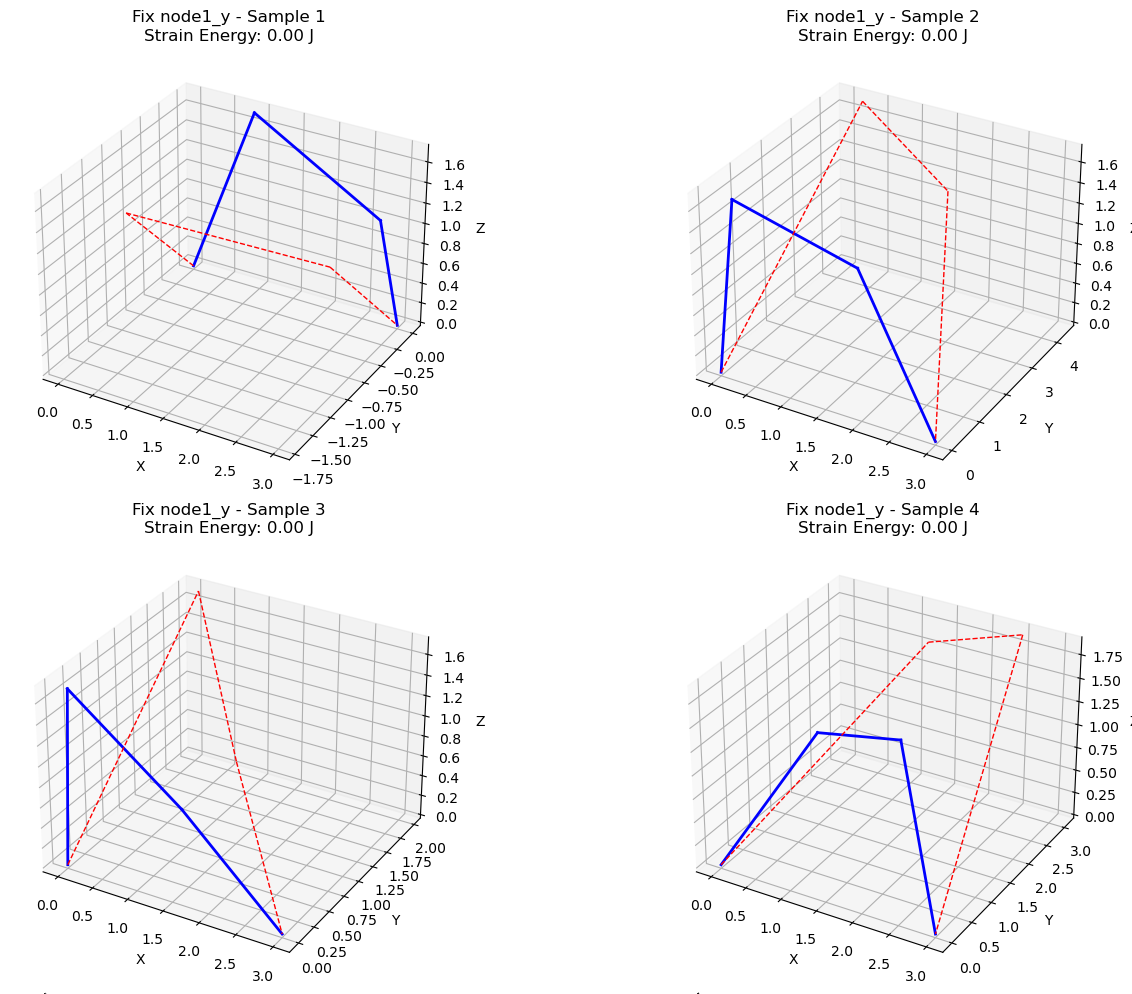

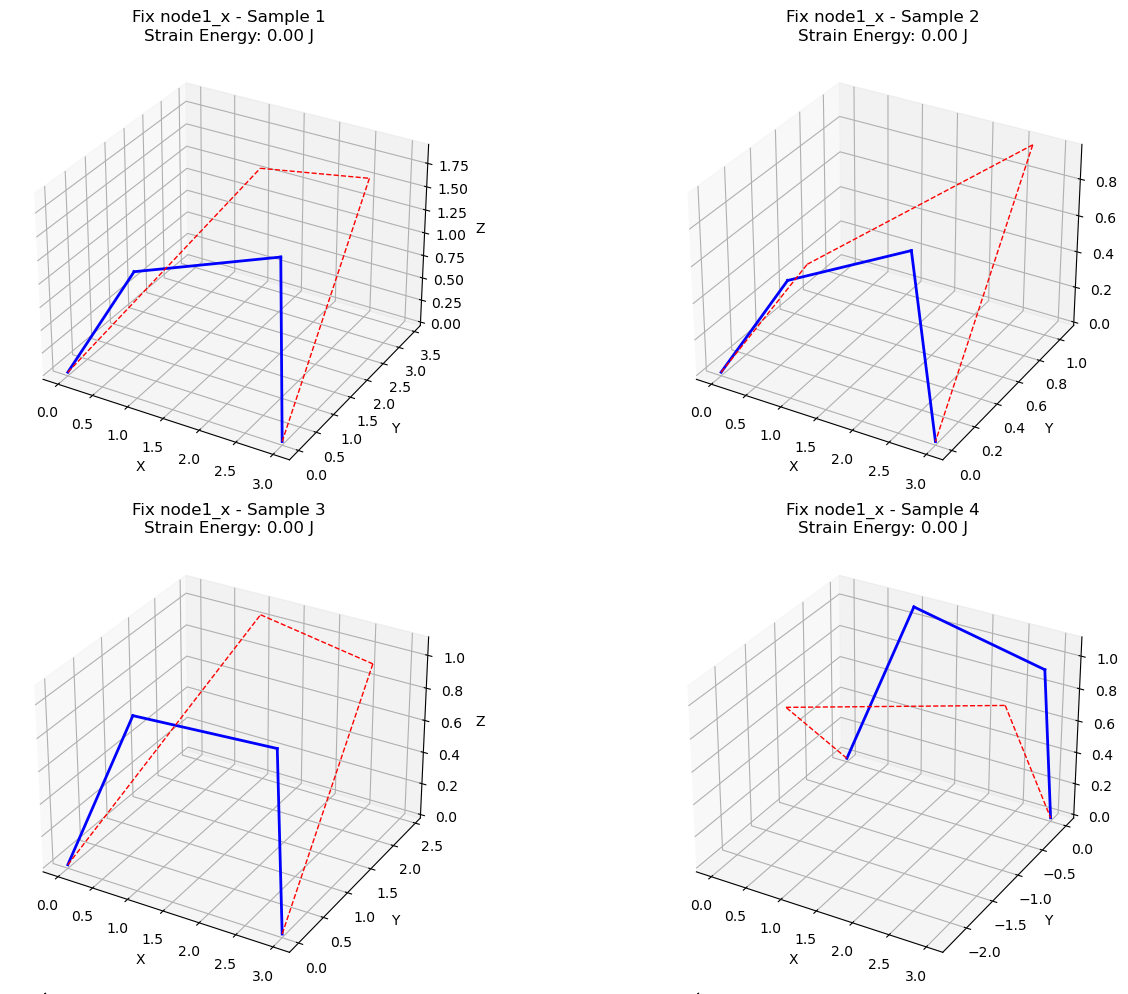


Fix node2_y abstract:
Sample    Max Force (mm) Strain Energy (J)   
1         127.6539       0.00                
2         143.0417       0.00                
3         153.6541       0.00                
4         110.7593       0.00                
5         143.8820       0.00                

Fix node2_x abstract:
Sample    Max Force (mm) Strain Energy (J)   
1         160.4198       0.00                
2         144.3011       0.00                
3         118.4148       0.00                
4         128.7544       0.00                
5         145.9711       0.00                

Fix node1_y abstract:
Sample    Max Force (mm) Strain Energy (J)   
1         167.6226       0.00                
2         158.2290       0.00                
3         144.7525       0.00                
4         127.6851       0.00                
5         125.1743       0.00                

Fix node1_x abstract:
Sample    Max Force (mm) Strain Energy (J)   
1         182.7910       0.00     

In [71]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Device setting
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Matrial Setting
D_radius = 0.75
D_young_modulus = 10e9 
D_shear_modulus = 0.7e9 
D_poisson_ratio = 0.3
cross_section_angle_a = 0  
cross_section_angle_b = 0  
a_small_number = 1e-10

# Sampling Params
n_samples = 5  # smampling amount
np.random.seed(42)  

# Baseline param
base_node1_x = 1.0    
base_node2_x = 2.0     
base_node1_y = np.sqrt(3) 
base_node2_y = np.sqrt(3)  

# RValue ranges (±50% Baselien values)
node1_x_range = (0.0, 1.5)    
node1_y_range = (0.0*np.sqrt(3), 2)
node2_x_range = (1.5, 3.0)     
node2_y_range = (0.5*np.sqrt(3), 2)

# Samnpling strategy
sample_groups = []

# Group 1：Varying: node1_x, node2_x, node1_y, Fixed: node2_y
group1 = np.column_stack([
    np.random.uniform(*node1_x_range, n_samples),
    np.random.uniform(*node1_y_range, n_samples),             
    np.random.uniform(*node2_x_range, n_samples),        
    np.full(n_samples, base_node2_y)             
])
sample_groups.append(('Fix node2_y', group1))

# Group2：Varying: node1_x, node1_y, node2_y，Fixed: node2_x  
group2 = np.column_stack([
    np.random.uniform(*node1_x_range, n_samples),
    np.random.uniform(*node1_y_range, n_samples), 
    np.full(n_samples, base_node2_x),
    np.random.uniform(*node2_y_range, n_samples)  
])
sample_groups.append(('Fix node2_x', group2))

# Group3：Varying: node1_x, node2_x, node2_y，Fixed: node1_y
group3 = np.column_stack([
    np.random.uniform(*node1_x_range, n_samples),
    np.full(n_samples, base_node1_y),
    np.random.uniform(*node2_x_range, n_samples),      
    np.random.uniform(*node2_y_range, n_samples) 
])
sample_groups.append(('Fix node1_y', group3))

# Group4：Varying: node1_x, node2_x, node1_y，Fixed: node1_x
group4 = np.column_stack([
    np.full(n_samples, base_node1_x),  
    np.random.uniform(*node1_y_range, n_samples), 
    np.random.uniform(*node2_x_range, n_samples),      
    np.random.uniform(*node2_y_range, n_samples)   
])
sample_groups.append(('Fix node1_x', group4))


def to_3d_coords(samples):
    """2D sampling to 3D (x,0,y)"""
    structures = []
    for sample in samples:
        node1 = torch.tensor([sample[0], 0, sample[1]], device=device)  
        node2 = torch.tensor([sample[2], 0, sample[3]], device=device)  
        fixed_A = torch.tensor([0, 0, 0], device=device)    
        fixed_B = torch.tensor([3, 0, 0], device=device)    
        
        structures.append({
            'nodes': [fixed_A, node1, node2, fixed_B],
            'connectivity': [
                (1, 2),  
                (2, 3),  
                (3, 4)   
            ]
        })
    return structures


all_structures = []
for group_name, samples in sample_groups:
    structures = to_3d_coords(samples)
    all_structures.append({
        'group_name': group_name,
        'samples': samples,
        'structures': structures
    })

def rotation(v, k, theta):
    """Rotation of vector v around axis k by angle theta."""
    k = k / torch.norm(k)  # Normalize k
    cross_product = torch.cross(k, v)
    dot_product = torch.dot(k, v)

    theta = torch.tensor(theta, dtype=torch.float32, device=device) if not isinstance(theta, torch.Tensor) else theta
    return v * torch.cos(theta) + cross_product * torch.sin(theta) + k * dot_product * (1 - torch.cos(theta))

class Beam:
    def __init__(self, node_coordinates, R=D_radius, young_modulus=D_young_modulus,
                 shear_modulus=D_shear_modulus, poisson_ratio=D_poisson_ratio, Beta_a=cross_section_angle_a,
                 Beta_b=cross_section_angle_b):
        self.node_coordinates = node_coordinates  # (2, 3) tensor for node coordinates
        self.radius = R
        self.young_modulus = young_modulus
        self.shear_modulus = shear_modulus
        self.poisson_ratio = poisson_ratio
        self.length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])
        self.Iy = (torch.pi * self.radius ** 4) / 4 
        self.Iz = self.Iy
        self.A = torch.pi * self.radius ** 2
        self.J = (torch.pi * self.radius ** 4) / 2
        
        self.S_u = self.young_modulus * self.A / self.length
        # self.S_v1a = 12 * self.young_modulus * self.Iy / (self.length ** 3)
        # self.S_v1b = 6 * self.young_modulus * self.Iy / (self.length ** 2)
        self.S_v2a = 12 * self.young_modulus * self.Iz / (self.length ** 3)
        self.S_v2b = 6 * self.young_modulus * self.Iz / (self.length ** 2)
        # self.S_theta1a = 6 * self.young_modulus * self.Iy / (self.length ** 2)
        # self.S_theta1b = 4 * self.young_modulus * self.Iy / self.length
        # self.S_theta1c = 2 * self.young_modulus * self.Iy / self.length
        self.S_theta2a = 6 * self.young_modulus * self.Iz / (self.length ** 2)
        self.S_theta2b = 4 * self.young_modulus * self.Iz / self.length
        self.S_theta2c = 2 * self.young_modulus * self.Iz / self.length
        # self.S_Tr = self.shear_modulus * self.J / self.length
        
        self.S_v1a = 1e10  
        self.S_v1b = 1e10 
        self.S_Tr = 1e10   
        self.S_theta1a = 1e10  
        self.S_theta1b = 1e10  
        self.S_theta1c = 1e10  
    
        
        S_u = self.S_u  
        S_v2a = self.S_v2a  
        S_v2b = self.S_v2b  
        S_theta2a = self.S_theta2a  
        S_theta2b = self.S_theta2b  
        S_theta2c = self.S_theta2c
            
        self.Beta_a = Beta_a
        self.Beta_b = Beta_b

    def get_element_stiffness_matrix(self):
        K_element = torch.tensor([
            [self.S_u, 0, 0, 0, 0, 0, -self.S_u, 0, 0, 0, 0, 0],
            [0, self.S_v1a, 0, 0, 0, self.S_theta1a, 0, -self.S_v1a, 0, 0, 0, self.S_theta1a],
            [0, 0, self.S_v2a, 0, -self.S_theta2a, 0, 0, 0, -self.S_v2a, 0, -self.S_theta2a, 0],
            [0, 0, 0, self.S_Tr, 0, 0, 0, 0, 0, -self.S_Tr, 0, 0],
            [0, 0, -self.S_v2b, 0, self.S_theta2b, 0, 0, 0, self.S_v2b, 0, self.S_theta2c, 0],
            [0, self.S_v1b, 0, 0, 0, self.S_theta1b, 0, -self.S_v1b, 0, 0, 0, self.S_theta1c],
            [-self.S_u, 0, 0, 0, 0, 0, self.S_u, 0, 0, 0, 0, 0],
            [0, -self.S_v1a, 0, 0, 0, -self.S_theta1a, 0, self.S_v1a, 0, 0, 0, -self.S_theta1a],
            [0, 0, -self.S_v2a, 0, self.S_theta2a, 0, 0, 0, self.S_v2a, 0, self.S_theta2a, 0],
            [0, 0, 0, -self.S_Tr, 0, 0, 0, 0, 0, self.S_Tr, 0, 0],
            [0, 0, -self.S_v2b, 0, self.S_theta2c, 0, 0, 0, self.S_v2b, 0, self.S_theta2b, 0],
            [0, self.S_v1b, 0, 0, 0, self.S_theta1c, 0, -self.S_v1b, 0, 0, 0, self.S_theta1b],
        ], dtype=torch.float32, device=device)
        return K_element

    def System_Transform(self):
        vector_x = self.node_coordinates[1, 0] - self.node_coordinates[0, 0]
        vector_y = self.node_coordinates[1, 1] - self.node_coordinates[0, 1]
        vector_z = self.node_coordinates[1, 2] - self.node_coordinates[0, 2]
        length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])
        z_value = torch.clamp(vector_z / length, min=-1 + 1e-6, max=1 - 1e-6)
        ceta = torch.acos(z_value)
        value = vector_x / torch.sqrt(vector_y ** 2 + vector_x ** 2 + a_small_number)
        value = torch.clamp(value, min=-1 + 1e-6, max=1 - 1e-6)
        alpha = torch.acos(value)

        Projection_Z_x = - vector_z / length * torch.sin(alpha)
        Projection_Z_y = - vector_z / length * torch.cos(alpha)
        Projection_Z_z = torch.cos(torch.pi / 2 - ceta)
        V_projection = torch.stack([Projection_Z_x, Projection_Z_y, Projection_Z_z])
        X_axis = torch.stack([vector_x / length, vector_y / length, vector_z / length])
        Z_axis_a = rotation(V_projection, X_axis, self.Beta_a)
        Y_axis_a = rotation(Z_axis_a, X_axis, -torch.pi / 2)
        Z_axis_a = Z_axis_a / torch.norm(Z_axis_a)
        Y_axis_a = Y_axis_a / torch.norm(Y_axis_a)
        lambda_matrix = torch.stack([X_axis, Y_axis_a, Z_axis_a], dim=0)
        matrix_T = torch.zeros((12, 12), dtype=torch.float32, device=device)
        for i in range(0, 12, 3):
            matrix_T[i:i + 3, i:i + 3] = lambda_matrix
        return matrix_T
        
def f_ext(Noord1, Noord2):
    x1 = Noord1[0]
    x2 = Noord2[0]
    F = torch.zeros(4 * 6, device=device)
    F[8] = -1000 * (0.5 * x1 +  0.5 * (x2-x1))
    F[14] = -1000 * (0.5 * (x2 - x1) +  0.5 * (3.0-x2))
    F[4] = -1000 * 0.25 * x1**2  
    F[10] = 1000 * (0.25 * x1**2 -  0.25 * (x2-x1)**2)
    F[16] = 1000 * (0.25 * (x2-x1)**2 -  0.25 * (3-x2)**2)
    F[22] = 1000 * 0.25 * (3-x2) ** 2
    return F
    
def analyze_structure(node_coords, connectivity, F):
    beams = []
    for i, j in connectivity:
        node_i = node_coords[i-1]
        node_j = node_coords[j-1]
        beams.append(Beam(torch.stack([node_i, node_j])))
    
    n_nodes = len(node_coords)
    n_dof_per_node = 6
    K_global = torch.zeros((n_nodes * n_dof_per_node, n_nodes * n_dof_per_node), device=device)
    
    for idx, (i, j) in enumerate(connectivity):
        T = beams[idx].System_Transform()
        K_e = torch.matmul(torch.matmul(T.T, beams[idx].get_element_stiffness_matrix()), T)
        dof_i = (i-1)*6
        dof_j = (j-1)*6
        K_global[dof_i:dof_i+6, dof_i:dof_i+6] += K_e[:6, :6]
        K_global[dof_j:dof_j+6, dof_j:dof_j+6] += K_e[6:, 6:]
        K_global[dof_i:dof_i+6, dof_j:dof_j+6] += K_e[:6, 6:]
        K_global[dof_j:dof_j+6, dof_i:dof_i+6] += K_e[6:, :6]
    
    fixed_dof = list(range(0, 6)) + list(range(18, 24)) 
    K_global[fixed_dof, :] = 0
    K_global[:, fixed_dof] = 0
    K_global[fixed_dof, fixed_dof] = 1e10
    displacements = torch.linalg.solve(K_global, F)
    forces = torch.matmul(K_global, displacements)
    strain_energy = 0.5 * torch.matmul(displacements, torch.matmul(K_global, displacements))
    
    return {
        'displacements': displacements,
        'forces': forces,
        'strain_energy': strain_energy,
    }

results = []
for group in all_structures:
    group_results = []
    for structure in group['structures']:
        F = f_ext(structure['nodes'][1], structure['nodes'][2])
        print(F)
        analysis_result = analyze_structure(structure['nodes'], structure['connectivity'], F)
        group_results.append(analysis_result)
    results.append({
        'group_name': group['group_name'],
        'results': group_results
    })

def plot_results(group_results):
    fig = plt.figure(figsize=(15, 10))
    for i, result in enumerate(group_results['results'][:4]):  
        ax = fig.add_subplot(2, 2, i+1, projection='3d')
        nodes = group_results['structures'][i]['nodes']
        
        # undisplaced
        for (start, end) in group_results['structures'][i]['connectivity']:
            start_node = nodes[start-1].cpu().numpy()
            end_node = nodes[end-1].cpu().numpy()
            ax.plot([start_node[0], end_node[0]], 
                    [start_node[1], end_node[1]], 
                    [start_node[2], end_node[2]], 'b-', linewidth=2)
        
        # displaced (50 times)
        disp_nodes = []
        for j in range(len(nodes)):
            disp = result['displacements'][j*6:j*6+3].cpu().numpy()
            disp_nodes.append(nodes[j].cpu().numpy() + disp * 50)
        
        for (start, end) in group_results['structures'][i]['connectivity']:
            start_node = disp_nodes[start-1]
            end_node = disp_nodes[end-1]
            ax.plot([start_node[0], end_node[0]], 
                    [start_node[1], end_node[1]], 
                    [start_node[2], end_node[2]], 'r--', linewidth=1)
        
        ax.set_title(f"{group_results['group_name']} - Sample {i+1}\n"
                    f"Strain Energy: {result['strain_energy'].item():.2f} J")
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
    
    plt.tight_layout()
    plt.show()


for group in results:
    plot_results({
        'group_name': group['group_name'],
        'structures': all_structures[[g['group_name'] for g in all_structures].index(group['group_name'])]['structures'],
        'results': group['results']
    })


for group in results:
    print(f"\n{group['group_name']} abstract:")
    print(f"{'Sample':<10}{'Max Force (mm)':<15}{'Strain Energy (J)':<20}")
    for i, result in enumerate(group['results']):
        mean_force = torch.mean(torch.abs(result['forces'])).item()   
        print(f"{i+1:<10}{mean_force:<15.4f}{result['strain_energy'].item():<20.2f}")

In [72]:
def f_re(f):
   F_re = torch.zeros(4 * 6, device=device)
   F_re[4] = - f[4]
   F_re[22] = - f[22]
   return F_re

In [73]:
initial_forces_results = []
reacted_forces_results = []
ultimate_forces_results = []  # New list for combined forces

for group in all_structures:
    group_initial_forces = []
    group_reaction_forces = []
    group_ultimate_forces = []  # New list for this group's combined forces
    
    for structure in group['structures']:
        # Step 1: Initial analysis with original F
        F = f_ext(structure['nodes'][1], structure['nodes'][2])
        initial_analysis = analyze_structure(structure['nodes'], structure['connectivity'], F)
        
        # Step 2: Compute reaction forces
        F_re = f_re(initial_analysis['forces'])
        
        # Step 3: Analyze with reaction forces
        reaction_analysis = analyze_structure(structure['nodes'], structure['connectivity'], F_re)
        
        # Step 4: Combine the forces
        ultimate_forces = initial_analysis['forces'] + reaction_analysis['forces']
        
        # Store results
        group_initial_forces.append(initial_analysis['forces'])
        group_reaction_forces.append(reaction_analysis['forces'])
        group_ultimate_forces.append(ultimate_forces)  # Store combined forces
    
    initial_forces_results.append({
        'group_name': group['group_name'],
        'forces': group_initial_forces
    })
    
    reacted_forces_results.append({
        'group_name': group['group_name'],
        'forces': group_reaction_forces
    })
    
    ultimate_forces_results.append({  # Store combined results for this group
        'group_name': group['group_name'],
        'forces': group_ultimate_forces
    })

# print("\nInitial forces results:")
# print(initial_forces_results)
# print("\nReacted forces results:")
# print(reacted_forces_results)
print("\nUltimate forces results:")
print(ultimate_forces_results)


Ultimate forces results:
[{'group_name': 'Fix node2_y', 'forces': [tensor([ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  4.8828e-04, -7.6544e+02, -1.5259e-05,
        -1.5587e+02,  0.0000e+00,  3.0518e-05, -6.1035e-05, -1.2191e+03,
         3.0518e-05, -3.0481e+02,  1.2207e-04,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00]), tensor([ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  4.5776e-05,  3.0518e-05, -1.4774e+03, -7.6294e-06,
        -7.5882e+01,  6.1035e-05, -9.5367e-05, -6.1035e-05, -7.8696e+02,
        -1.5259e-05,  5.8379e+02, -6.1035e-05,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00]), tensor([ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  3.8147e-05,  0.0000e+00, -1.3743e+03,  1.5259e-05,
        -3.7978e+02, -6.1035e-05, -4.8995e-05, -2.2888e-05, -9.5100e+02,
     

In [75]:
# 存储最终符合条件的组
valid_groups = []

for group_idx, group in enumerate(ultimate_forces_results):
    group_data = all_structures[group_idx]  
    group_valid_structures = []
    
    for struct_idx, forces in enumerate(group['forces']):
        elem_7 = forces[6].item()
        elem_9 = forces[8].item()
        elem_13 = forces[12].item()
        elem_15 = forces[14].item()
        
        # 计算比值
        ratio1 = elem_9 / elem_7 if elem_7 != 0 else float('1.0')
        ratio2 = elem_15 / elem_13 if elem_13 != 0 else float('1.0')
        print(ratio1,ratio2)
        
        # 获取节点坐标
        node1 = group_data['structures'][struct_idx]['nodes'][1]  
        node2 = group_data['structures'][struct_idx]['nodes'][2]  
        
        # 计算坐标比值
        coord_ratio1 = node1[1] / node1[0] if node1[0] != 0 else float('1.0')
        coord_ratio2 = node2[1] / node2[0] if node2[0] != 0 else float('1.0')
        print(coord_ratio1,coord_ratio2)
        
        # 计算误差
        error1 = abs(ratio1 - coord_ratio1) / coord_ratio1 if coord_ratio1 != 0 and coord_ratio1 != float('inf') else float('inf')
        error2 = abs(ratio2 - coord_ratio2) / coord_ratio2 if coord_ratio2 != 0 and coord_ratio2 != float('inf') else float('inf')
        
        # 检查误差是否在10%以内
        if error1 <= 0.5 and error2 <= 0.5:
            group_valid_structures.append({
                'structure_idx': struct_idx,
                'force_ratios': (ratio1, ratio2),
                'coord_ratios': (coord_ratio1, coord_ratio2),
                'errors': (error1, error2)
            })
    
    if group_valid_structures:  # 如果这组有符合条件的结构
        valid_groups.append({
            'group_name': group['group_name'],
            'group_idx': group_idx,
            'valid_structures': group_valid_structures
        })

print(valid_groups)
print("\n符合误差不超过10%的组:")
for group in valid_groups:
    print(f"\n组名: {group['group_name']} (索引: {group['group_idx']})")
    for struct in group['valid_structures']:
        print(f"  结构索引: {struct['structure_idx']}")
        print(f"  力比值: {struct['force_ratios']}")
        print(f"  坐标比值: {struct['coord_ratios']}")
        print(f"  误差: {struct['errors']}")
        print("  -------------------")

1.0 -39947296.0
tensor(0., dtype=torch.float64) tensor(0., dtype=torch.float64)
-32275005.333333332 8251919.36
tensor(0., dtype=torch.float64) tensor(0., dtype=torch.float64)
-36027289.6 19410228.94403893
tensor(0., dtype=torch.float64) tensor(0., dtype=torch.float64)
-23835556.8 11479792.0
tensor(0., dtype=torch.float64) tensor(0., dtype=torch.float64)
-14522267.0 -15105893.333333334
tensor(0., dtype=torch.float64) tensor(0., dtype=torch.float64)
-18724565.714285713 1.0
tensor(0., dtype=torch.float64) tensor(0., dtype=torch.float64)
6241523.80952381 -20837476.0
tensor(0., dtype=torch.float64) tensor(0., dtype=torch.float64)
-12192744.930232558 36255580.0
tensor(0., dtype=torch.float64) tensor(0., dtype=torch.float64)
14979653.485714287 34254684.44444445
tensor(0., dtype=torch.float64) tensor(0., dtype=torch.float64)
-131072000.0 167979008.0
tensor(0., dtype=torch.float64) tensor(0., dtype=torch.float64)
-29628778.666666668 -8555244.0
tensor(0., dtype=torch.float64) tensor(0., dtype=to

In [51]:
selected_forces = []

for group in ultimate_forces_results:
    group_selected = []
    for forces in group['forces']:
        element_10 = forces[10].item()  
        element_16 = forces[16].item()
        group_selected.append({
            'en_10': element_10,
            'en_16': element_16
        })
    
    selected_forces.append({
        'group_name': group['group_name'],
        'selected_elements': group_selected
    })

print("\nSelected forces (elements 10 and 16):")
print(selected_forces)


Selected forces (elements 10 and 16):
[{'group_name': 'Fix node2_y', 'selected_elements': [{'en_10': 86.86166381835938, 'en_16': -442.82421875}, {'en_10': 266.45306396484375, 'en_16': 189.44100952148438}, {'en_10': 76.70538330078125, 'en_16': 191.33868408203125}, {'en_10': 207.61160278320312, 'en_16': -320.3662109375}, {'en_10': -155.47955322265625, 'en_16': -171.32701110839844}]}, {'group_name': 'Fix node2_x', 'selected_elements': [{'en_10': -316.59552001953125, 'en_16': 183.35577392578125}, {'en_10': -195.7578125, 'en_16': 107.458984375}, {'en_10': 24.756362915039062, 'en_16': -12.224845886230469}, {'en_10': -68.05496215820312, 'en_16': 35.18534851074219}, {'en_10': -208.77088928222656, 'en_16': 115.2816162109375}]}, {'group_name': 'Fix node1_y', 'selected_elements': [{'en_10': -53.84783935546875, 'en_16': 240.9332275390625}, {'en_10': -209.13909912109375, 'en_16': -35.6971435546875}, {'en_10': -186.7554931640625, 'en_16': -225.05419921875}, {'en_10': 389.6331787109375, 'en_16': -31